# NB 03 — Operator Interpolation

2D interpolants over the $(k, S)$ parameter grid so that reduced operators $\hat{A}^*$, $\hat{B}^*$, $\hat{C}^*$ can be evaluated at any new parameter point $(k^*, S^*)$ without running MRST.

*Ref.* Peherstorfer & Willcox (2016), Section 2.3 final paragraph — *elementwise interpolation of reduced operators*.

---


The paper uses elementwise spline interpolation over a 1D parameter space. This space is 2D: $(k, S)$. For each scalar entry $[\hat{A}(\mu)]_{ij}$ we fit an independent 2D interpolant over the training grid, then evaluate it at any query point.


Physical behaviour (transmissibility, MTR slope, BHP drawdown) scales linearly with $k$ on a log axis. Interpolating on raw $k$ values would cluster accuracy near $k = 500$ mD and give poor results at $k = 5$ mD. We therefore interpolate over $(\log_{10} k,\; S)$ space.

`scipy.interpolate.RBFInterpolator` with a thin-plate-spline kernel. This is exact at training points, smooth between them, and handles the irregular case where some high-skin / high-k points may have been excluded as unstable in Notebook 02.

---

## Output

| File | Content |
|---|---|
| `rom/interpolants/A_hat_interp.pkl` | One `RBFInterpolator` per $(i,j)$ entry of $\hat{A}$ — $n^2$ objects |
| `rom/interpolants/B_hat_interp.pkl` | $n$ objects (one per row of $\hat{B}$) |
| `rom/interpolants/C_hat_interp.pkl` | $n$ objects (one per column of $\hat{C}$) |
| `rom/interpolants/interp_metadata.json` | Parameter grid, stable points used, method |

---
## 0. Imports and paths

In [1]:
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.interpolate import RBFInterpolator

plt.rcParams.update({'figure.dpi': 120, 'axes.grid': True,
                     'grid.alpha': 0.3, 'axes.spines.top': False,
                     'axes.spines.right': False})

BASIS_DIR  = Path('../rom/basis_CO')
OPS_DIR    = Path('../rom/operators_CO')
INTERP_DIR = Path('../rom/interpolants_CO')
INTERP_DIR.mkdir(parents=True, exist_ok=True)

K_GRID = [5, 10, 20, 50, 100, 200, 500]
S_GRID = [0,  2,  5,  8,  10,  12,  15]

Vn = np.load(BASIS_DIR / 'Vn.npy')
n  = Vn.shape[1]
print(f'n modes : {n}')
print(f'Interp dir : {INTERP_DIR.resolve()}')

n modes : 6
Interp dir : F:\Niloy Deb\Part Two\reservoir_rom_CO\rom\interpolants_CO


---
## 1. Load all inferred operators

Only **stable** parameter points are used for interpolation. Unstable points (flagged in Notebook 02) are excluded because their $\hat{A}$ matrices have corrupted entries driven by ill-conditioning rather than true physics — including them would poison the interpolant.

In [2]:
log10k_pts, S_pts = [], []
A_list, B_list, C_list = [], [], []
excluded = []

for k in K_GRID:
    for s in S_GRID:
        tag     = f'k{k:03d}_s{s:02d}'
        op_dir  = OPS_DIR / tag

        if not (op_dir / 'A_hat.npy').exists():
            excluded.append((tag, 'missing'))
            continue

        with open(op_dir / 'inference_report.json') as f:
            rep = json.load(f)

        if not rep['stable']:
            excluded.append((tag, f'unstable  max_eig={rep["max_real_eig"]:.3f}'))
            continue

        log10k_pts.append(np.log10(k))
        S_pts.append(s)
        A_list.append(np.load(op_dir / 'A_hat.npy'))
        B_list.append(np.load(op_dir / 'B_hat.npy'))
        C_list.append(np.load(op_dir / 'C_hat.npy'))

pts = np.column_stack([log10k_pts, S_pts])   # [M, 2]  interpolation coordinates

A_arr = np.array(A_list)   # [M, n, n]
B_arr = np.array(B_list)   # [M, n, 1]
C_arr = np.array(C_list)   # [M, 1, n]

print(f'Training points used : {len(log10k_pts)} / 49')
if excluded:
    print(f'Excluded             : {len(excluded)}')
    for tag, reason in excluded:
        print(f'  {tag}  ({reason})')
print(f'Interpolation coords : log10(k) in [{pts[:,0].min():.2f}, {pts[:,0].max():.2f}]')
print(f'                       S        in [{pts[:,1].min():.0f}, {pts[:,1].max():.0f}]')

Training points used : 49 / 49
Interpolation coords : log10(k) in [0.70, 2.70]
                       S        in [0, 15]


---
## 2. Build interpolants

For each scalar entry of each operator we fit one `RBFInterpolator`. The total number of interpolants is $n^2 + n + n$ (for $\hat{A}$, $\hat{B}$, $\hat{C}$ respectively). At $n = 10$ this is 120 objects — fast to build and evaluate.

In [3]:
def build_interp_grid(arr, pts, kernel='thin_plate_spline'):
    """
    Build one RBFInterpolator per scalar entry.
    arr shape: [M, d1, d2, ...]  ->  returns nested list matching [d1, d2, ...]
    """
    shape    = arr.shape[1:]
    n_scalar = int(np.prod(shape))
    arr_flat = arr.reshape(len(arr), n_scalar)   # [M, n_scalar]
    interps  = []
    for col in range(n_scalar):
        interps.append(RBFInterpolator(pts, arr_flat[:, col],
                                       kernel=kernel, smoothing=0.0))
    return interps, shape


print('Building A interpolants...')
A_interps, A_shape = build_interp_grid(A_arr, pts)

print('Building B interpolants...')
B_interps, B_shape = build_interp_grid(B_arr, pts)

print('Building C interpolants...')
C_interps, C_shape = build_interp_grid(C_arr, pts)

print(f'\nInterpolants built:')
print(f'  A : {len(A_interps)} (shape {A_shape})')
print(f'  B : {len(B_interps)} (shape {B_shape})')
print(f'  C : {len(C_interps)} (shape {C_shape})')

Building A interpolants...
Building B interpolants...
Building C interpolants...

Interpolants built:
  A : 36 (shape (6, 6))
  B : 6 (shape (6, 1))
  C : 6 (shape (1, 6))


---
## 3. Leave-one-out cross-validation

For each training point we remove it, refit the interpolant on the remaining points, and evaluate at the removed point. The interpolation error measures how accurately operators at unseen parameter values will be recovered — distinct from the ROM prediction error tested in Notebook 04.

We report the relative Frobenius norm error for $\hat{A}$ (the dominant operator), averaged over the leave-one-out folds.

Leave-one-out interpolation error for Â:
  Mean  : 6.76e+00
  Max   : 6.72e+01
  Worst : index 6,  log10k=0.70,  S=15


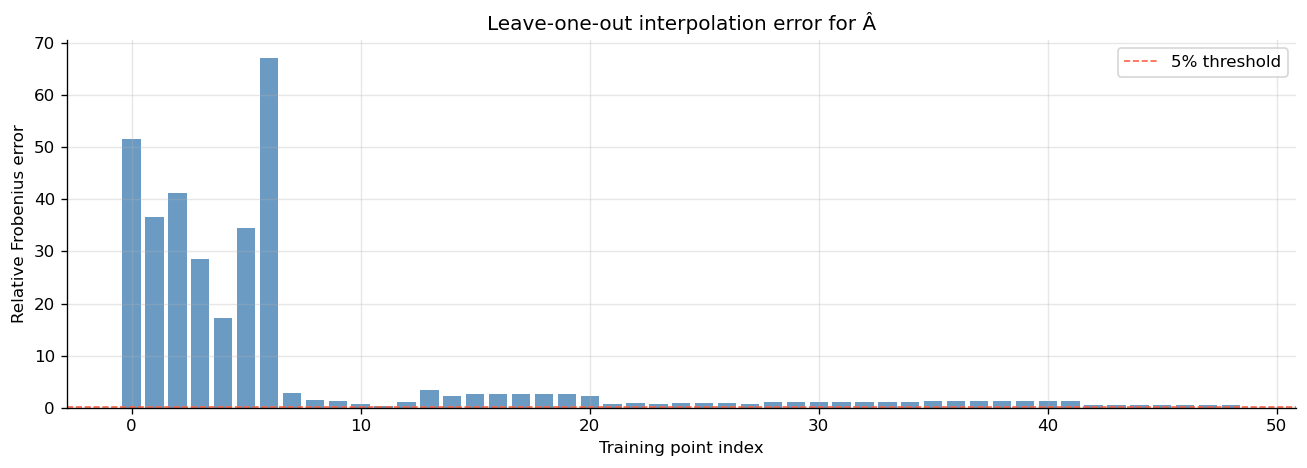

In [4]:
M = len(log10k_pts)
loo_A_errors = []

for held in range(M):
    train_mask = np.arange(M) != held
    pts_train  = pts[train_mask]
    A_train    = A_arr[train_mask]          # [M-1, n, n]
    A_held     = A_arr[held]                # [n, n]
    pt_query   = pts[[held]]                # [1, 2]

    A_flat_train = A_train.reshape(M - 1, n * n)
    A_pred_flat  = np.zeros(n * n)

    for col in range(n * n):
        rbf          = RBFInterpolator(pts_train, A_flat_train[:, col],
                                       kernel='thin_plate_spline', smoothing=0.0)
        A_pred_flat[col] = rbf(pt_query)[0]

    A_pred = A_pred_flat.reshape(n, n)
    err    = np.linalg.norm(A_pred - A_held, 'fro') / np.linalg.norm(A_held, 'fro')
    loo_A_errors.append(err)

loo_errors = np.array(loo_A_errors)
tags_used  = [f'k{K_GRID[j % len(K_GRID)]}_s{S_GRID[j // len(K_GRID)]}'
              for j in range(M)]

print(f'Leave-one-out interpolation error for Â:')
print(f'  Mean  : {loo_errors.mean():.2e}')
print(f'  Max   : {loo_errors.max():.2e}')
print(f'  Worst : index {np.argmax(loo_errors)},  log10k={pts[np.argmax(loo_errors),0]:.2f},  S={pts[np.argmax(loo_errors),1]:.0f}')

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(range(M), loo_errors, color='steelblue', alpha=0.8)
ax.axhline(0.05, color='tomato', ls='--', lw=1, label='5% threshold')
ax.set_xlabel('Training point index')
ax.set_ylabel('Relative Frobenius error')
ax.set_title('Leave-one-out interpolation error for Â')
ax.legend()
plt.tight_layout()
plt.show()

---
## 4. Interpolation surface visualisation

Visualise how two representative operator entries vary over the $(k, S)$ parameter space. Smooth, physically monotone surfaces confirm the interpolant is well-behaved. Jagged or non-monotone surfaces in a region suggest that the training data in that corner is insufficient or numerically noisy.

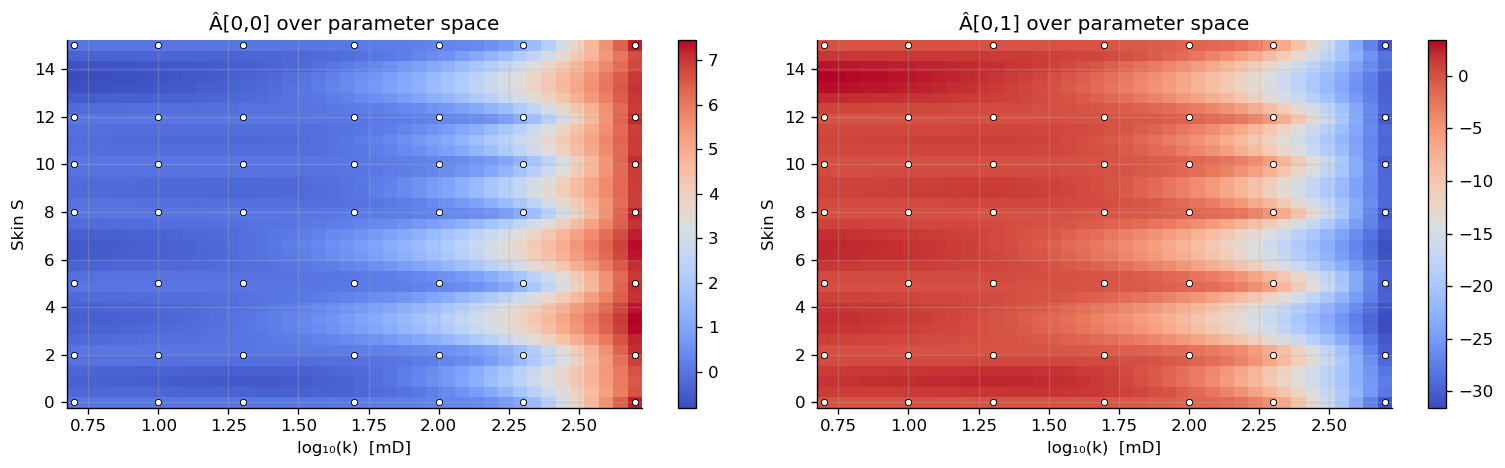

In [5]:
def eval_operator(interps, shape, k_query, s_query):
    pt  = np.array([[np.log10(k_query), s_query]])
    vals = np.array([f(pt)[0] for f in interps])
    return vals.reshape(shape)


k_fine = np.logspace(np.log10(5), np.log10(500), 40)
s_fine = np.linspace(0, 15, 35)
KK, SS = np.meshgrid(k_fine, s_fine)

entry_00 = np.zeros_like(KK)
entry_01 = np.zeros_like(KK)
for i in range(KK.shape[0]):
    for j in range(KK.shape[1]):
        A_q = eval_operator(A_interps, A_shape, KK[i,j], SS[i,j])
        entry_00[i,j] = A_q[0, 0]
        entry_01[i,j] = A_q[0, 1]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

im0 = axes[0].pcolormesh(np.log10(KK), SS, entry_00, cmap='coolwarm', shading='auto')
axes[0].set_xlabel('log₁₀(k)  [mD]')
axes[0].set_ylabel('Skin S')
axes[0].set_title('Â[0,0] over parameter space')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].pcolormesh(np.log10(KK), SS, entry_01, cmap='coolwarm', shading='auto')
axes[1].set_xlabel('log₁₀(k)  [mD]')
axes[1].set_ylabel('Skin S')
axes[1].set_title('Â[0,1] over parameter space')
plt.colorbar(im1, ax=axes[1])

for ax in axes:
    ax.scatter(np.log10(K_GRID * len(S_GRID)),
               np.repeat(S_GRID, len(K_GRID)),
               c='k', s=8, zorder=5, label='training pts')
    ax.scatter(pts[:,0], pts[:,1], c='white', s=14,
               edgecolors='black', linewidths=0.5, zorder=6)

plt.tight_layout()
plt.show()

---
## 5. Save interpolants

In [6]:
with open(INTERP_DIR / 'A_hat_interp.pkl', 'wb') as f:
    pickle.dump({'interps': A_interps, 'shape': A_shape}, f)

with open(INTERP_DIR / 'B_hat_interp.pkl', 'wb') as f:
    pickle.dump({'interps': B_interps, 'shape': B_shape}, f)

with open(INTERP_DIR / 'C_hat_interp.pkl', 'wb') as f:
    pickle.dump({'interps': C_interps, 'shape': C_shape}, f)

meta = {
    'k_grid'          : K_GRID,
    'S_grid'          : S_GRID,
    'n_modes'         : int(n),
    'n_training_pts'  : int(M),
    'n_excluded'      : len(excluded),
    'excluded_cases'  : [e[0] for e in excluded],
    'kernel'          : 'thin_plate_spline',
    'interp_coords'   : 'log10(k), S',
    'loo_mean_error'  : float(loo_errors.mean()),
    'loo_max_error'   : float(loo_errors.max()),
}
with open(INTERP_DIR / 'interp_metadata.json', 'w') as f:
    json.dump(meta, f, indent=2)

print('Saved:')
for p in sorted(INTERP_DIR.iterdir()):
    print(f'  {p.name:<30}  {p.stat().st_size/1e3:.1f} kB')
print(f'\nReady for Notebook 04 — Validation')

Saved:
  A_hat_interp.pkl                55.9 kB
  B_hat_interp.pkl                10.3 kB
  C_hat_interp.pkl                10.3 kB
  interp_metadata.json            0.4 kB

Ready for Notebook 04 — Validation
